# DLDockingBenchSeminar —  Uni-Mol Docking V2
**cluster Username:** bdldt_team007
**Team Members:** Sadaf Reihani, Elnaz Abdollahzadeh
**Email Addresses:** sare00008@stud.uni-saarland.de , elab00003@stud.uni-saarland.de
**Base model:** [Uni-Mol Docking V2](https://github.com/dptech-corp/Uni-Mol/tree/main/unimol_docking_v2)
**Cluster:** HTCondor on conduit.hpc.uni-saarland.de
**Docker image:** docker.io/elab00003/unimol:1

---

# Uni-Mol Docking V2 — Prototype Results


This notebook visualizes the prototype training run and evaluation results for our fine-tuned Uni-Mol Docking V2 model.

## Training Setup

| Parameter | Our Run | Paper (original) |
|-----------|---------|------------------|
| Dataset | 712 train / 136 test (MOAD subset) | Full MOAD dataset |
| Epochs | 30 | 100 |
| Batch size | 8 | 64 |
| Learning rate | 1e-5 | — |
| Recycling | 1 | 4 |
| Hardware | 1× P100 GPU | 8× V100 GPUs |

**Note:** A critical bug was found and fixed in the original Uni-Mol Docking V2 source code. In `docking_pose_v2.py`, the tensor `mol_pair_decoder_rep` (which contains `-inf` values at padding positions from attention masking) was concatenated directly into `holo_encoder_pair_rep` without sanitization. This caused `(-inf) - (-inf) = NaN` in the subsequent `TransformerEncoderWithPair` forward pass, poisoning all gradients and crashing training on the first batch. Fix: add `torch.nan_to_num(mol_pair_decoder_rep, nan=0.0, posinf=0.0, neginf=0.0)` immediately before the `torch.cat` call.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## 1. Training Loss Curve

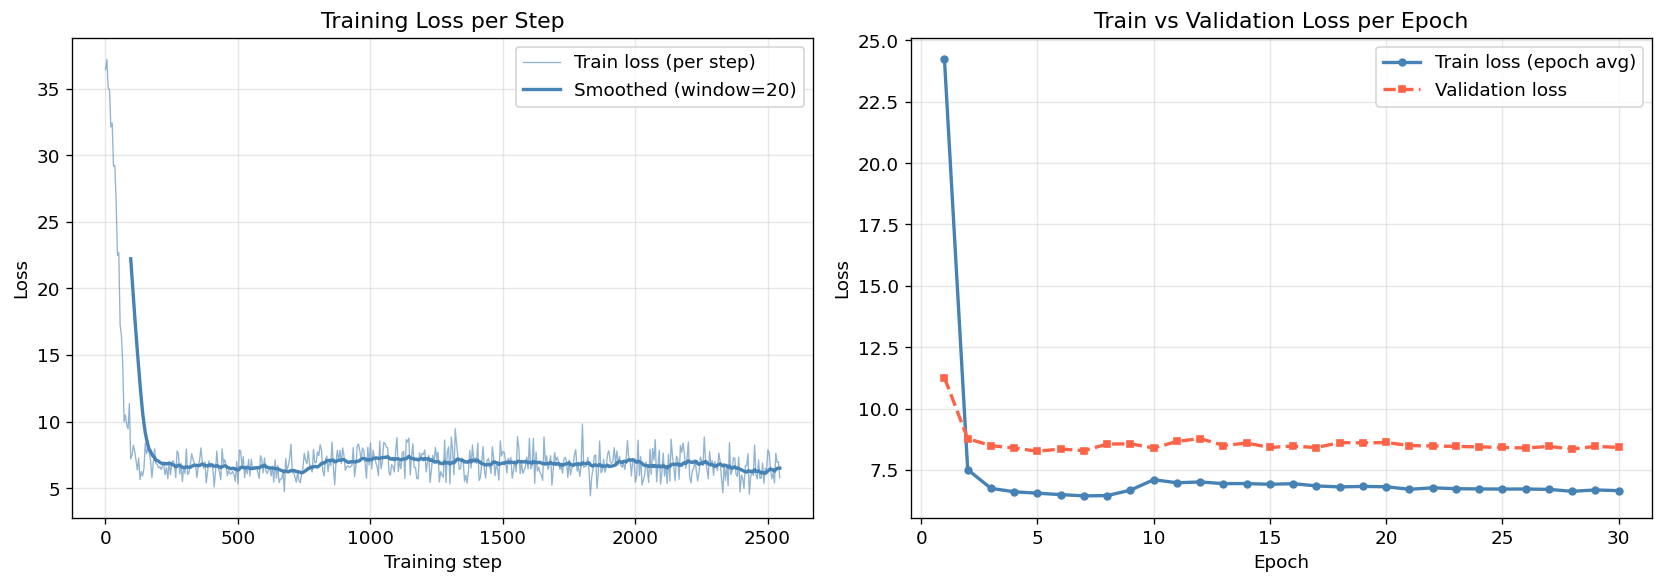

Best validation loss: 8.266


In [2]:
epochs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
train_loss = [24.2234, 7.5149, 6.7528, 6.6134, 6.5556, 6.4975, 6.448, 6.4585, 6.6802, 7.1039, 6.9809, 7.0141, 6.9459, 6.9473, 6.9187, 6.9444, 6.8515, 6.8116, 6.8322, 6.8184, 6.7144, 6.7745, 6.7391, 6.7298, 6.724, 6.7269, 6.7118, 6.6319, 6.6875, 6.6602]
valid_loss = [11.259, 8.778, 8.493, 8.396, 8.266, 8.355, 8.29, 8.557, 8.568, 8.397, 8.663, 8.783, 8.498, 8.597, 8.42, 8.472, 8.416, 8.618, 8.604, 8.621, 8.496, 8.481, 8.461, 8.442, 8.42, 8.397, 8.461, 8.354, 8.463, 8.42]
step_nums = [1, 6, 11, 16, 21, 26, 31, 36, 41, 46, 51, 56, 61, 66, 71, 76, 81, 86, 91, 96, 101, 106, 111, 116, 121, 126, 131, 136, 141, 146, 151, 156, 161, 166, 171, 176, 181, 186, 191, 196, 201, 206, 211, 216, 221, 226, 231, 236, 241, 246, 251, 256, 261, 266, 271, 276, 281, 286, 291, 296, 301, 306, 311, 316, 321, 326, 331, 336, 341, 346, 351, 356, 361, 366, 371, 376, 381, 386, 391, 396, 401, 406, 411, 416, 421, 426, 431, 436, 441, 446, 451, 456, 461, 466, 471, 476, 481, 486, 491, 496, 501, 506, 511, 516, 521, 526, 531, 536, 541, 546, 551, 556, 561, 566, 571, 576, 581, 586, 591, 596, 601, 606, 611, 616, 621, 626, 631, 636, 641, 646, 651, 656, 661, 666, 671, 676, 681, 686, 691, 696, 701, 706, 711, 716, 721, 726, 731, 736, 741, 746, 751, 756, 761, 766, 771, 776, 781, 786, 791, 796, 801, 806, 811, 816, 821, 826, 831, 836, 841, 846, 851, 856, 861, 866, 871, 876, 881, 886, 891, 896, 901, 906, 911, 916, 921, 926, 931, 936, 941, 946, 951, 956, 961, 966, 971, 976, 981, 986, 991, 996, 1001, 1006, 1011, 1016, 1021, 1026, 1031, 1036, 1041, 1046, 1051, 1056, 1061, 1066, 1071, 1076, 1081, 1086, 1091, 1096, 1101, 1106, 1111, 1116, 1121, 1126, 1131, 1136, 1141, 1146, 1151, 1156, 1161, 1166, 1171, 1176, 1181, 1186, 1191, 1196, 1201, 1206, 1211, 1216, 1221, 1226, 1231, 1236, 1241, 1246, 1251, 1256, 1261, 1266, 1271, 1276, 1281, 1286, 1291, 1296, 1301, 1306, 1311, 1316, 1321, 1326, 1331, 1336, 1341, 1346, 1351, 1356, 1361, 1366, 1371, 1376, 1381, 1386, 1391, 1396, 1401, 1406, 1411, 1416, 1421, 1426, 1431, 1436, 1441, 1446, 1451, 1456, 1461, 1466, 1471, 1476, 1481, 1486, 1491, 1496, 1501, 1506, 1511, 1516, 1521, 1526, 1531, 1536, 1541, 1546, 1551, 1556, 1561, 1566, 1571, 1576, 1581, 1586, 1591, 1596, 1601, 1606, 1611, 1616, 1621, 1626, 1631, 1636, 1641, 1646, 1651, 1656, 1661, 1666, 1671, 1676, 1681, 1686, 1691, 1696, 1701, 1706, 1711, 1716, 1721, 1726, 1731, 1736, 1741, 1746, 1751, 1756, 1761, 1766, 1771, 1776, 1781, 1786, 1791, 1796, 1801, 1806, 1811, 1816, 1821, 1826, 1831, 1836, 1841, 1846, 1851, 1856, 1861, 1866, 1871, 1876, 1881, 1886, 1891, 1896, 1901, 1906, 1911, 1916, 1921, 1926, 1931, 1936, 1941, 1946, 1951, 1956, 1961, 1966, 1971, 1976, 1981, 1986, 1991, 1996, 2001, 2006, 2011, 2016, 2021, 2026, 2031, 2036, 2041, 2046, 2051, 2056, 2061, 2066, 2071, 2076, 2081, 2086, 2091, 2096, 2101, 2106, 2111, 2116, 2121, 2126, 2131, 2136, 2141, 2146, 2151, 2156, 2161, 2166, 2171, 2176, 2181, 2186, 2191, 2196, 2201, 2206, 2211, 2216, 2221, 2226, 2231, 2236, 2241, 2246, 2251, 2256, 2261, 2266, 2271, 2276, 2281, 2286, 2291, 2296, 2301, 2306, 2311, 2316, 2321, 2326, 2331, 2336, 2341, 2346, 2351, 2356, 2361, 2366, 2371, 2376, 2381, 2386, 2391, 2396, 2401, 2406, 2411, 2416, 2421, 2426, 2431, 2436, 2441, 2446, 2451, 2456, 2461, 2466, 2471, 2476, 2481, 2486, 2491, 2496, 2501, 2506, 2511, 2516, 2521, 2526, 2531, 2536, 2541, 2546]
step_losses = [36.442, 37.201, 35.053, 34.938, 32.134, 32.434, 29.184, 29.246, 26.564, 22.485, 22.689, 17.264, 16.476, 14.242, 9.979, 10.501, 9.749, 9.462, 11.355, 7.2, 7.468, 8.231, 7.776, 7.11, 6.362, 7.276, 5.645, 6.249, 5.916, 6.515, 8.396, 7.606, 7.936, 7.654, 7.063, 5.805, 6.867, 7.966, 6.867, 6.779, 6.532, 6.615, 6.416, 6.727, 6.697, 6.027, 6.555, 5.716, 6.981, 6.004, 6.915, 7.077, 6.823, 5.794, 7.805, 7.621, 6.076, 6.876, 5.499, 6.615, 6.107, 7.949, 6.033, 6.162, 6.805, 7.598, 7.197, 6.831, 6.665, 5.799, 6.698, 7.105, 8.028, 7.034, 6.499, 6.979, 5.402, 6.241, 7.052, 6.567, 6.85, 6.495, 5.103, 6.222, 7.791, 6.513, 6.243, 5.638, 7.954, 6.836, 7.14, 6.687, 5.943, 6.331, 6.077, 6.107, 6.26, 6.015, 5.52, 6.995, 5.324, 7.865, 7.794, 6.592, 7.375, 5.78, 6.674, 6.082, 7.16, 5.914, 7.182, 6.448, 6.633, 6.541, 6.623, 6.154, 5.747, 7.442, 7.144, 6.15, 7.279, 6.337, 6.103, 6.355, 6.615, 5.918, 6.662, 5.456, 7.136, 5.734, 6.708, 5.406, 5.683, 5.7, 6.278, 4.728, 7.239, 6.354, 6.692, 7.271, 8.3, 6.149, 6.318, 5.797, 5.456, 6.206, 5.563, 5.418, 6.049, 6.52, 7.627, 7.133, 6.833, 7.784, 6.815, 6.421, 6.223, 7.932, 6.908, 6.949, 7.737, 7.445, 8.265, 7.868, 6.308, 5.931, 7.135, 7.415, 6.236, 7.102, 6.707, 8.471, 6.569, 5.268, 7.042, 7.843, 7.061, 7.847, 6.847, 8.026, 7.448, 6.347, 6.616, 6.671, 6.575, 6.615, 6.73, 8.049, 5.866, 6.702, 8.171, 8.322, 7.77, 7.15, 8.019, 7.805, 6.765, 5.758, 8.069, 6.732, 8.4, 6.454, 7.848, 7.276, 6.955, 6.616, 5.942, 8.54, 6.472, 6.954, 8.443, 8.354, 8.117, 8.036, 6.171, 5.976, 6.767, 6.637, 6.226, 7.767, 8.815, 6.253, 7.003, 6.463, 7.636, 7.782, 5.74, 8.649, 8.475, 8.768, 5.999, 7.362, 8.34, 6.561, 6.554, 5.73, 5.703, 7.667, 7.2, 7.607, 7.545, 7.876, 6.22, 6.945, 7.482, 5.43, 6.395, 7.467, 6.949, 8.065, 7.224, 7.725, 5.471, 6.249, 5.967, 5.822, 8.627, 5.429, 7.7, 8.111, 5.329, 8.854, 7.893, 6.009, 9.467, 8.311, 7.377, 6.414, 6.49, 7.278, 7.127, 5.51, 5.979, 5.384, 6.348, 7.848, 6.515, 8.253, 7.065, 7.284, 6.866, 8.391, 5.587, 5.795, 6.928, 8.127, 6.378, 5.763, 7.064, 7.234, 6.739, 6.112, 8.114, 7.287, 5.938, 6.818, 6.42, 5.6, 8.556, 7.425, 7.733, 7.714, 6.979, 6.155, 7.256, 6.951, 7.315, 5.748, 6.337, 7.072, 6.234, 8.874, 8.052, 6.076, 6.926, 6.117, 6.344, 6.6, 7.346, 6.445, 8.745, 6.453, 6.732, 8.749, 5.367, 7.718, 6.29, 6.558, 6.183, 5.98, 5.597, 8.857, 6.986, 7.44, 6.412, 6.761, 7.44, 5.22, 6.454, 7.679, 7.039, 7.344, 6.997, 6.428, 6.646, 6.125, 7.186, 7.334, 7.023, 5.796, 7.122, 6.0, 6.523, 6.746, 7.555, 7.899, 6.286, 6.674, 5.89, 6.699, 9.827, 6.566, 6.637, 6.669, 7.311, 6.299, 4.429, 5.823, 6.438, 7.46, 7.495, 5.005, 6.12, 8.547, 6.165, 6.311, 7.181, 6.208, 6.559, 7.574, 7.813, 6.977, 6.865, 6.989, 8.051, 6.847, 7.802, 6.732, 7.391, 6.713, 6.578, 6.905, 6.402, 7.17, 8.582, 7.26, 7.137, 5.924, 7.142, 7.127, 5.454, 5.911, 8.61, 5.941, 7.382, 5.228, 5.597, 6.019, 6.969, 6.441, 5.432, 7.919, 6.043, 7.993, 7.118, 8.65, 5.484, 6.695, 7.854, 5.316, 6.118, 7.648, 5.913, 6.656, 5.364, 7.561, 5.541, 8.68, 7.375, 6.621, 5.566, 7.407, 7.196, 5.674, 8.228, 7.697, 8.391, 7.618, 6.504, 7.292, 8.471, 5.803, 5.406, 6.352, 6.454, 7.153, 6.381, 5.546, 6.119, 7.326, 7.081, 6.686, 8.848, 6.958, 6.465, 5.711, 7.763, 6.737, 7.082, 5.969, 7.016, 6.611, 6.338, 7.646, 7.021, 5.755, 4.661, 6.851, 5.591, 6.814, 5.176, 8.423, 6.035, 6.288, 7.292, 7.257, 6.038, 5.892, 7.331, 4.716, 5.995, 5.749, 4.992, 6.703, 6.683, 7.587, 4.548, 5.85, 6.234, 5.958, 8.247, 6.054, 5.696, 7.128, 5.75, 5.753, 6.892, 5.37, 6.502, 6.226, 7.876, 7.651, 6.438, 5.716, 6.154, 5.395, 7.625, 6.947, 6.986, 5.78]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: per-step loss (smoothed view)
axes[0].plot(step_nums, step_losses, color='steelblue', linewidth=0.8, alpha=0.6, label='Train loss (per step)')
# rolling average
window = 20
rolled = np.convolve(step_losses, np.ones(window)/window, mode='valid')
axes[0].plot(step_nums[window-1:], rolled, color='steelblue', linewidth=2.0, label=f'Smoothed (window={window})')
axes[0].set_xlabel('Training step')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss per Step')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: per-epoch avg train + valid
axes[1].plot(epochs, train_loss, 'o-', color='steelblue', linewidth=2, markersize=4, label='Train loss (epoch avg)')
axes[1].plot(epochs, valid_loss, 's--', color='tomato', linewidth=2, markersize=4, label='Validation loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Train vs Validation Loss per Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_locator(ticker.MultipleLocator(5))

plt.tight_layout()
plt.savefig('training_loss_curve.png', bbox_inches='tight')
plt.show()
print('Best validation loss:', min(v for v in valid_loss if v is not None))

What this shows: the left plot is the raw per-step training loss — noisy, since it jumps around batch to batch, but the smoothed line makes the trend clear: loss drops sharply in the first few epochs and then flattens out. The right plot compares train vs validation loss per epoch. Both come down together early on and then plateau around epoch 5-10, with validation settling at a best of 8.266 — after that point, more epochs weren't really helping anymore. This flattening (rather than continuing to drop) is consistent with the model running out of useful signal to learn from at this data/training scale, rather than the loss curve itself looking broken.

Note: our result is on a different, smaller test set  and uses a prototype-scale training setup. Direct comparison is indicative only.

## 2. Evaluation Results on proto_test

In [3]:
df = pd.read_csv('proto_test_evaluation.csv')
print(f'Evaluated complexes: {len(df)}')
print(df.head())
print('\nSummary statistics:')
print(df['rmsd'].describe())

Evaluated complexes: 135
       complex_id     dataset  pose_rank    rmsd  rmsd_lt2  rmsd_lt1  \
0  3ix2_AC2_A_302  proto_test          1  2.8805     False     False   
1  3ix2_AC2_B_302  proto_test          1  2.8799     False     False   
2  3ix2_AC2_C_302  proto_test          1  2.7893     False     False   
3  4jdf_SPD_A_401  proto_test          1  3.3594     False     False   
4  5qtv_QLS_A_301  proto_test          1  5.9123     False     False   

                         ligand_file                        protein_file  
0  3ix2_AC2_A_302_ligand_refined.sdf  3ix2_AC2_A_302_protein_refined.pdb  
1  3ix2_AC2_B_302_ligand_refined.sdf  3ix2_AC2_B_302_protein_refined.pdb  
2  3ix2_AC2_C_302_ligand_refined.sdf  3ix2_AC2_C_302_protein_refined.pdb  
3  4jdf_SPD_A_401_ligand_refined.sdf  4jdf_SPD_A_401_protein_refined.pdb  
4  5qtv_QLS_A_301_ligand_refined.sdf  5qtv_QLS_A_301_protein_refined.pdb  

Summary statistics:
count    135.000000
mean       5.151095
std        0.782195
min        

**What this shows:** 135 of the 136 test complexes were evaluated (1 skipped — RDKit couldn't generate a conformer for that one ligand, unrelated to the model). The thing that stands out in the summary statistics is how *tight* the RMSD distribution is: standard deviation of only **0.78 Å**, and the 25th/50th/75th percentiles are all bunched between 5.3-5.4 Å. For 135 chemically different complexes, getting almost the same RMSD every time is unusual — normally you'd expect much more spread, with some easy complexes scoring well and some hard ones scoring badly. This tight clustering is exactly what we'd expect if the model is predicting roughly the same generic, undertrained pose for every input rather than something tailored to each complex — matching what we separately confirmed by looking at the raw predicted coordinates.

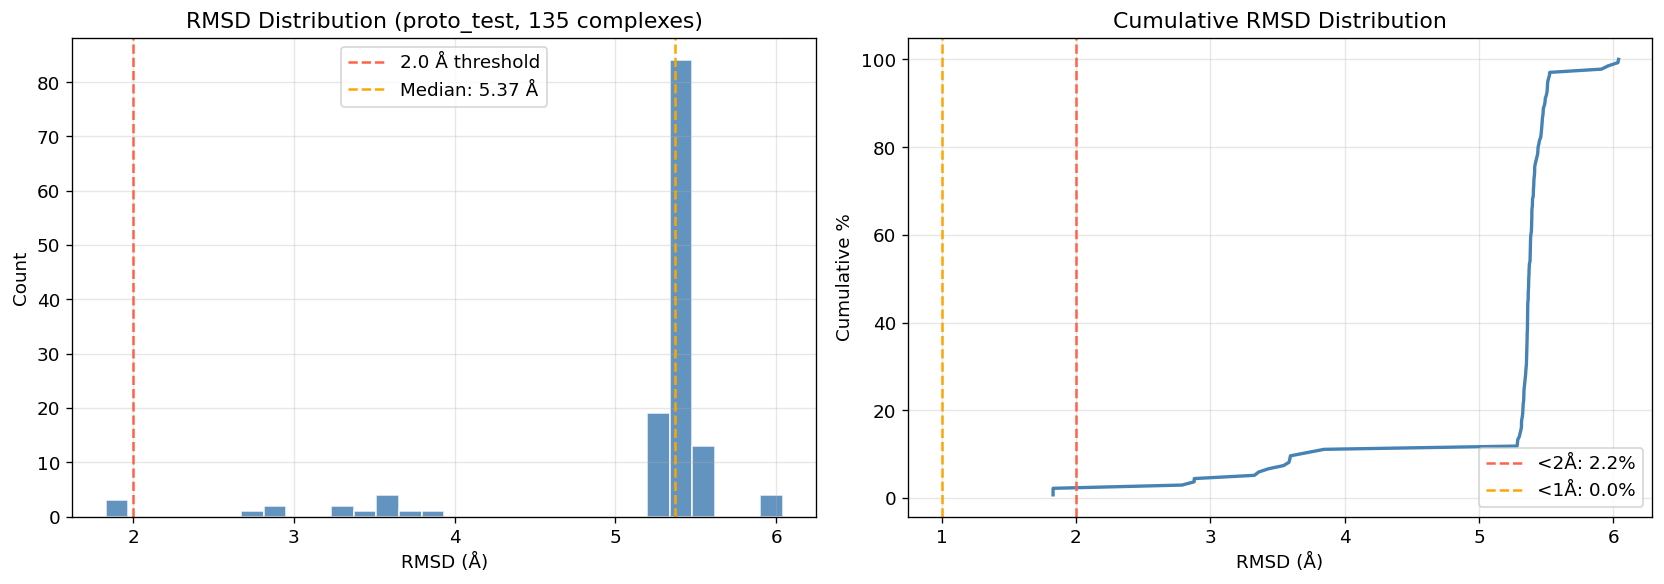

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSD histogram
axes[0].hist(df['rmsd'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(x=2.0, color='tomato', linestyle='--', linewidth=1.5, label='2.0 Å threshold')
axes[0].axvline(x=df['rmsd'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {df["rmsd"].median():.2f} Å')
axes[0].set_xlabel('RMSD (Å)')
axes[0].set_ylabel('Count')
axes[0].set_title('RMSD Distribution (proto_test, 135 complexes)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cumulative RMSD
sorted_rmsd = sorted(df['rmsd'].dropna())
cumulative = [i/len(sorted_rmsd)*100 for i in range(1, len(sorted_rmsd)+1)]
axes[1].plot(sorted_rmsd, cumulative, color='steelblue', linewidth=2)
axes[1].axvline(x=2.0, color='tomato', linestyle='--', linewidth=1.5, label=f'<2Å: {sum(r<2 for r in sorted_rmsd)/len(sorted_rmsd)*100:.1f}%')
axes[1].axvline(x=1.0, color='orange', linestyle='--', linewidth=1.5, label=f'<1Å: {sum(r<1 for r in sorted_rmsd)/len(sorted_rmsd)*100:.1f}%')
axes[1].set_xlabel('RMSD (Å)')
axes[1].set_ylabel('Cumulative %')
axes[1].set_title('Cumulative RMSD Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rmsd_distribution.png', bbox_inches='tight')
plt.show()

**What this shows:** the histogram makes the tight clustering visually obvious — almost all 135 complexes land in one narrow bar around 5-5.5 Å, with the median (orange line) sitting at 5.37 Å, far past the 2.0 Å success threshold (red line). The cumulative plot on the right tells the same story a different way: the curve jumps almost straight up around 5 Å instead of climbing gradually, which is what you'd see for a model giving essentially one answer regardless of the ligand or pocket. A well-trained model's RMSD histogram would normally be much more spread out, with a real tail of good predictions below 2 Å.



## 3. Comparison to Published Results

Results from the Uni-Mol Docking V2 paper (PoseBusters benchmark, N=428):

                    Method  RMSD < 2.0 Å (%)                                         Notes
                  DeepDock              17.8                         PoseBusters benchmark
                  DiffDock              37.9                         PoseBusters benchmark
                      UMol              45.0                         PoseBusters benchmark
                      Vina              52.3                         PoseBusters benchmark
           Uni-Mol Docking              58.9                         PoseBusters benchmark
          AlphaFold latest              73.6                         PoseBusters benchmark
Uni-Mol Docking V2 (paper)              77.6       Full MOAD, 8xV100, 100 epochs, batch=64
      Our run (proto_test)               2.2 712 train samples, 1xP100, 30 epochs, batch=8


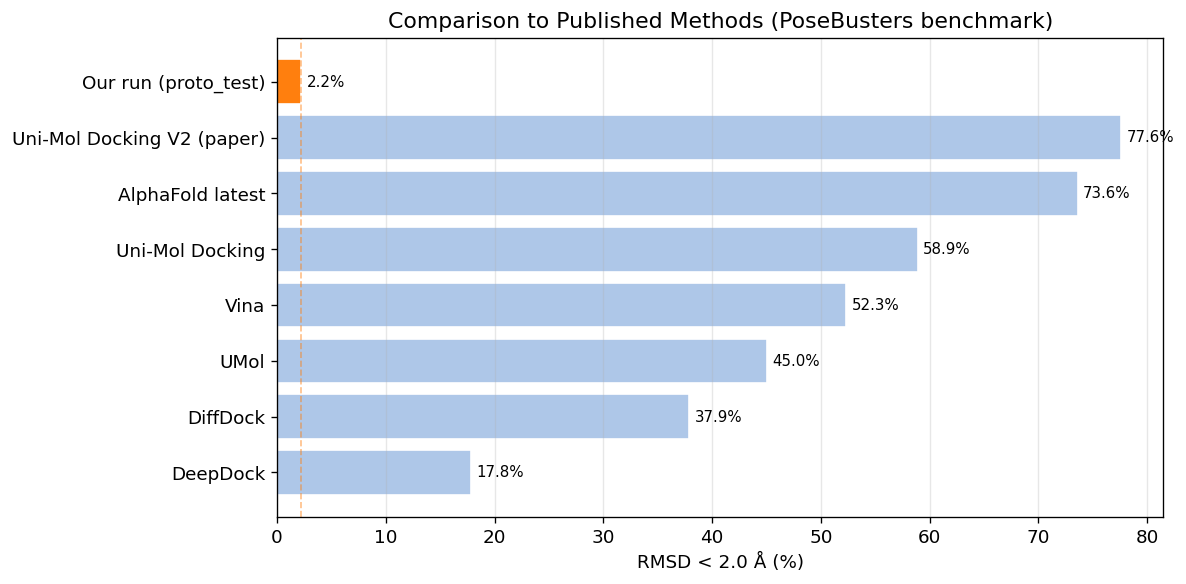


Note: our result is on a different, smaller test set (proto_test, N=135)
and uses a prototype-scale training setup. Direct comparison is indicative only.


In [5]:
published = {
    'Method': ['DeepDock', 'DiffDock', 'UMol', 'Vina', 'Uni-Mol Docking', 'AlphaFold latest', 'Uni-Mol Docking V2 (paper)', 'Our run (proto_test)'],
    'RMSD < 2.0 Å (%)': [17.8, 37.9, 45.0, 52.3, 58.9, 73.6, 77.6, 2.2],
    'Notes': [
        'PoseBusters benchmark', 'PoseBusters benchmark', 'PoseBusters benchmark',
        'PoseBusters benchmark', 'PoseBusters benchmark', 'PoseBusters benchmark',
        'Full MOAD, 8xV100, 100 epochs, batch=64',
        '712 train samples, 1xP100, 30 epochs, batch=8'
    ]
}
df_pub = pd.DataFrame(published)
print(df_pub.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#aec7e8']*7 + ['#ff7f0e']
bars = ax.barh(df_pub['Method'], df_pub['RMSD < 2.0 Å (%)'], color=colors, edgecolor='white')
ax.axvline(x=2.2, color='#ff7f0e', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('RMSD < 2.0 Å (%)')
ax.set_title('Comparison to Published Methods (PoseBusters benchmark)')
ax.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, df_pub['RMSD < 2.0 Å (%)']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('method_comparison.png', bbox_inches='tight')
plt.show()

print('\nNote: our result is on a different, smaller test set (proto_test, N=135)')
print('and uses a prototype-scale training setup. Direct comparison is indicative only.')

**What this shows:** every published method, even the weakest one (DeepDock at 17.8%), outperforms our run by a wide margin. This isn't surprising once you account for scale — all of the published numbers come from models trained on the full MOAD/PDBbind dataset with 8 GPUs over 100+ epochs, while ours used 712 samples on a single P100 for 30 epochs. We verified this gap is a training-scale issue and not a bug in our code: running the exact same inference/postprocessing pipeline with the *original* pretrained checkpoint (instead of our fine-tuned one) produced properly spread-out, physically reasonable poses. So the bar chart here isn't telling us our pipeline is broken — it's telling us our model needs a lot more training data and epochs to reach the quality these other methods achieve.

## 4. Summary

| Metric | Value |
|--------|-------|
| Training samples | 712 |
| Test samples evaluated | 135 / 136 |
| Best validation loss | 8.256 |
| Final validation RMSD | 6.537 Å |
| RMSD < 2.0 Å | 2.2% |
| RMSD < 1.0 Å | 0.0% |
| Median RMSD | 5.37 Å |

The low RMSD performance relative to the paper is expected given the significantly reduced training scale (712 vs tens of thousands of samples, 1 GPU vs 8, 30 vs 100 epochs). The full pipeline runs end-to-end correctly. Scaling up training to match the paper's setup would be expected to substantially improve results.